# Análisis Exploratorio Visual - Student Test Score Prediction

## Objetivo
Realizar análisis exploratorio visual de cada variable vs `exam_score` para identificar las más relevantes y seleccionar las mejores para modelado.

## Contexto
La búsqueda exhaustiva de 1,816 combinaciones tomaría **~70 horas** (benchmark: 138s por combinación).

**Este enfoque visual toma solo 5-10 minutos** y permite selección informada de variables.

## Dataset
- 630,000 registros
- 11 variables predictoras (4 numéricas + 7 categóricas)
- Target: exam_score (continuo)

## 1. Setup e Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

print("✓ Librerías cargadas")
print("✓ Configuración de visualización lista")

✓ Librerías cargadas
✓ Configuración de visualización lista


## 2. Carga de Datos

In [2]:
# Ruta del archivo
DATA_PATH = r"C:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\DGKaggle\Playground Series\Season 6\Episode 1 - Predicting Student Test Scores\data\train.csv"

# Cargar datos
print("Cargando datos...")
df = pd.read_csv(DATA_PATH)

# Variables categóricas y numéricas
categorical_features = [
    'gender', 'course', 'internet_access',
    'sleep_quality', 'study_method',
    'facility_rating', 'exam_difficulty'
]

numerical_features = [
    'age', 'study_hours', 'class_attendance', 'sleep_hours'
]

print(f"\n{'='*80}")
print("DATASET CARGADO")
print(f"{'='*80}")
print(f"Registros: {len(df):,}")
print(f"Variables numéricas: {len(numerical_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Target: exam_score")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'='*80}")

Cargando datos...

DATASET CARGADO
Registros: 630,000
Variables numéricas: 4
Variables categóricas: 7
Target: exam_score
Memoria: 257.28 MB


In [3]:
# Vista previa
df.head(1)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3


In [4]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


## 3. Estadísticas Descriptivas

In [5]:
# Estadísticas del target
print("\n" + "="*80)
print("ESTADÍSTICAS DE EXAM_SCORE (Target)")
print("="*80)
print(df['exam_score'].describe())
print(f"\nRango: {df['exam_score'].min():.2f} - {df['exam_score'].max():.2f}")
print(f"Mediana: {df['exam_score'].median():.2f}")
print(f"Desviación estándar: {df['exam_score'].std():.2f}")
print("="*80)


ESTADÍSTICAS DE EXAM_SCORE (Target)
count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

Rango: 19.60 - 100.00
Mediana: 62.60
Desviación estándar: 18.92


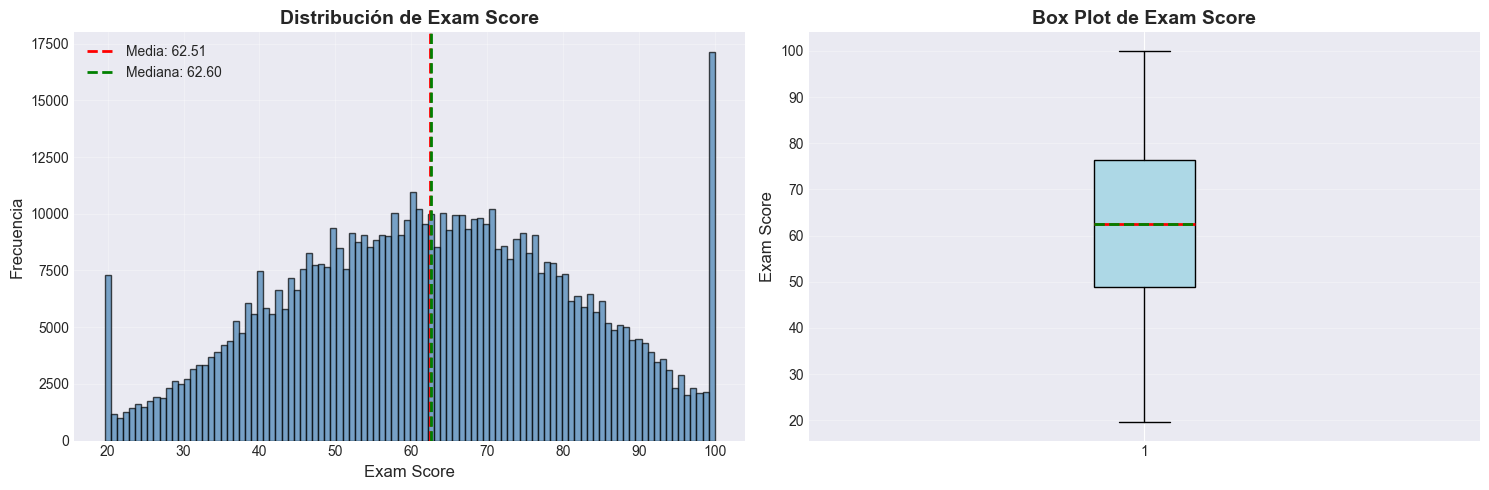

✓ Distribución del target visualizada


In [6]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
axes[0].hist(df['exam_score'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["exam_score"].mean():.2f}')
axes[0].axvline(df['exam_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["exam_score"].median():.2f}')
axes[0].set_xlabel('Exam Score', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Exam Score', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['exam_score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                showmeans=True, meanline=True,
                meanprops=dict(color='green', linestyle='--', linewidth=2))
axes[1].set_ylabel('Exam Score', fontsize=12)
axes[1].set_title('Box Plot de Exam Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Distribución del target visualizada")

## 4. Análisis de Variables Numéricas vs Target

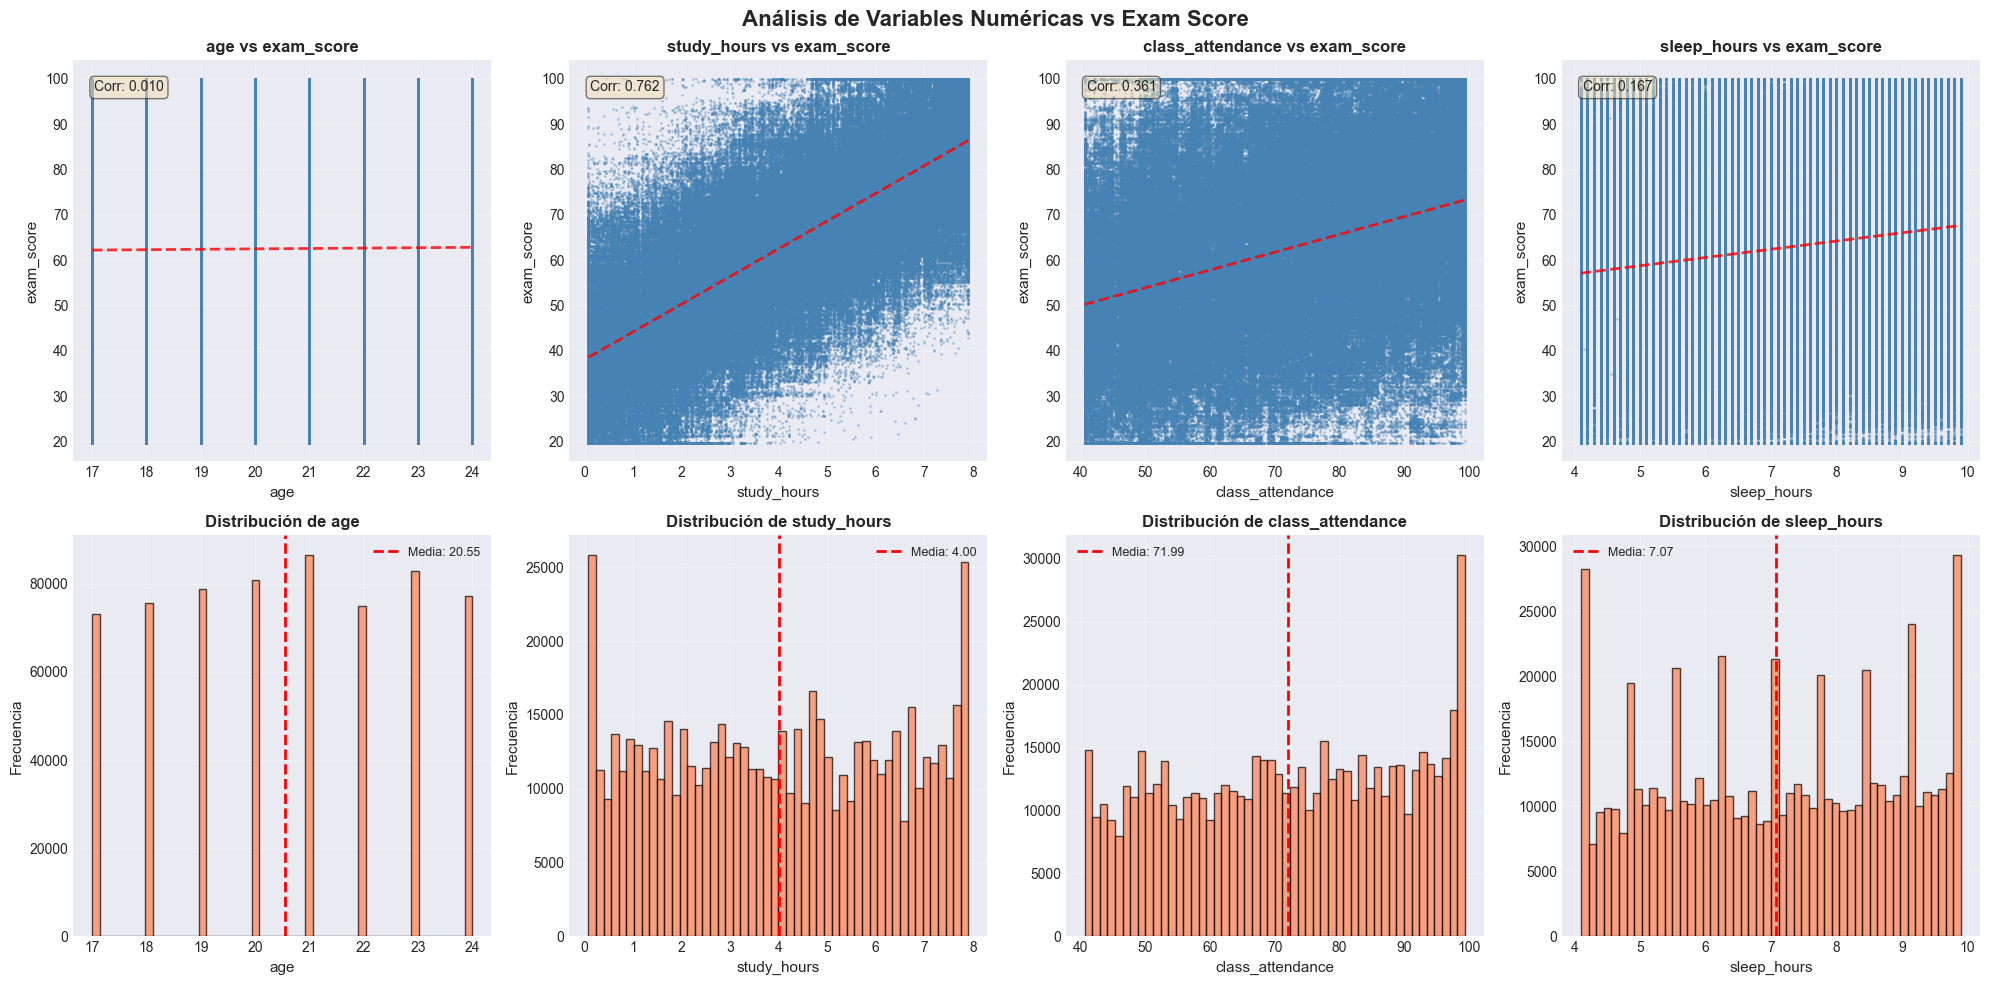

✓ Análisis de variables numéricas guardado en 'numerical_analysis.png'


In [7]:
# Crear grid de subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Análisis de Variables Numéricas vs Exam Score', fontsize=16, fontweight='bold')

for idx, var in enumerate(numerical_features):
    # Scatter plot
    ax1 = axes[0, idx]
    ax1.scatter(df[var], df['exam_score'], alpha=0.3, s=1, color='steelblue')
    ax1.set_xlabel(var, fontsize=11)
    ax1.set_ylabel('exam_score', fontsize=11)
    ax1.set_title(f'{var} vs exam_score', fontweight='bold')
    
    # Calcular correlación
    corr = df[var].corr(df['exam_score'])
    ax1.text(0.05, 0.95, f'Corr: {corr:.3f}',
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Línea de tendencia
    z = np.polyfit(df[var], df['exam_score'], 1)
    p = np.poly1d(z)
    ax1.plot(df[var].sort_values(), p(df[var].sort_values()), "r--", alpha=0.8, linewidth=2)
    
    ax1.grid(True, alpha=0.3)
    
    # Distribución de la variable
    ax2 = axes[1, idx]
    ax2.hist(df[var], bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax2.axvline(df[var].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[var].mean():.2f}')
    ax2.set_xlabel(var, fontsize=11)
    ax2.set_ylabel('Frecuencia', fontsize=11)
    ax2.set_title(f'Distribución de {var}', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Análisis de variables numéricas guardado en 'numerical_analysis.png'")

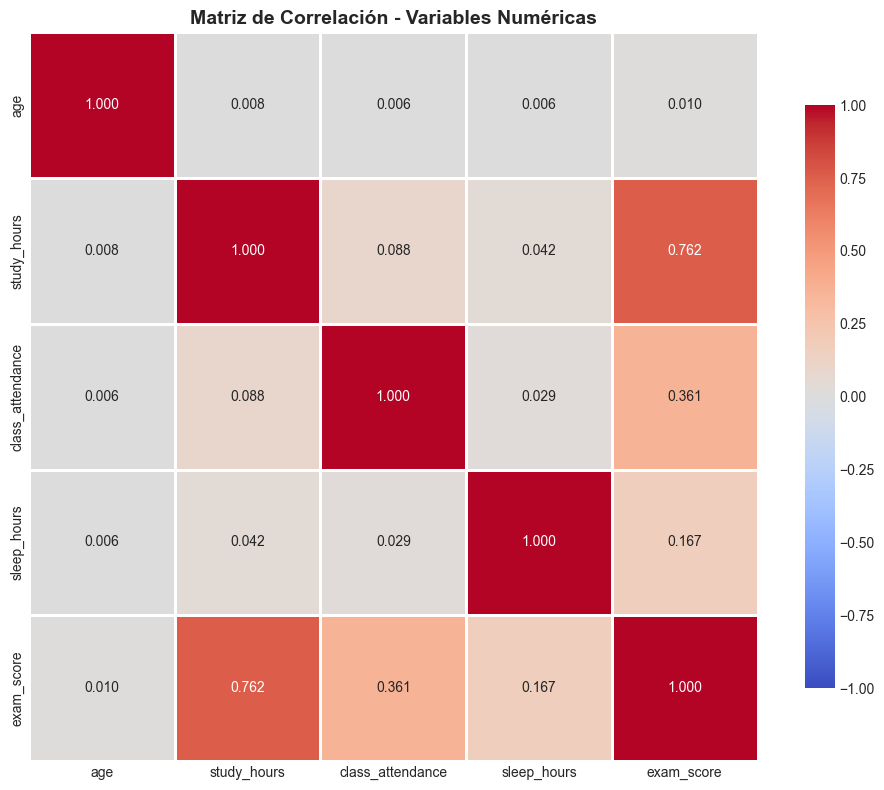

✓ Matriz de correlación guardada en 'correlation_matrix.png'


In [8]:
# Matriz de correlación
corr_data = df[numerical_features + ['exam_score']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Matriz de correlación guardada en 'correlation_matrix.png'")

In [9]:
# Mostrar correlaciones con target ordenadas
print("\n" + "="*80)
print("CORRELACIONES CON EXAM_SCORE (Variables Numéricas)")
print("="*80)
target_corrs = corr_data['exam_score'].drop('exam_score').sort_values(ascending=False)
for var, corr in target_corrs.items():
    bar = '█' * int(abs(corr) * 50)
    print(f"{var:20s}: {corr:7.4f}  {bar}")
print("="*80)


CORRELACIONES CON EXAM_SCORE (Variables Numéricas)
study_hours         :  0.7623  ██████████████████████████████████████
class_attendance    :  0.3610  ██████████████████
sleep_hours         :  0.1674  ████████
age                 :  0.0105  


## 5. Análisis de Variables Categóricas vs Target

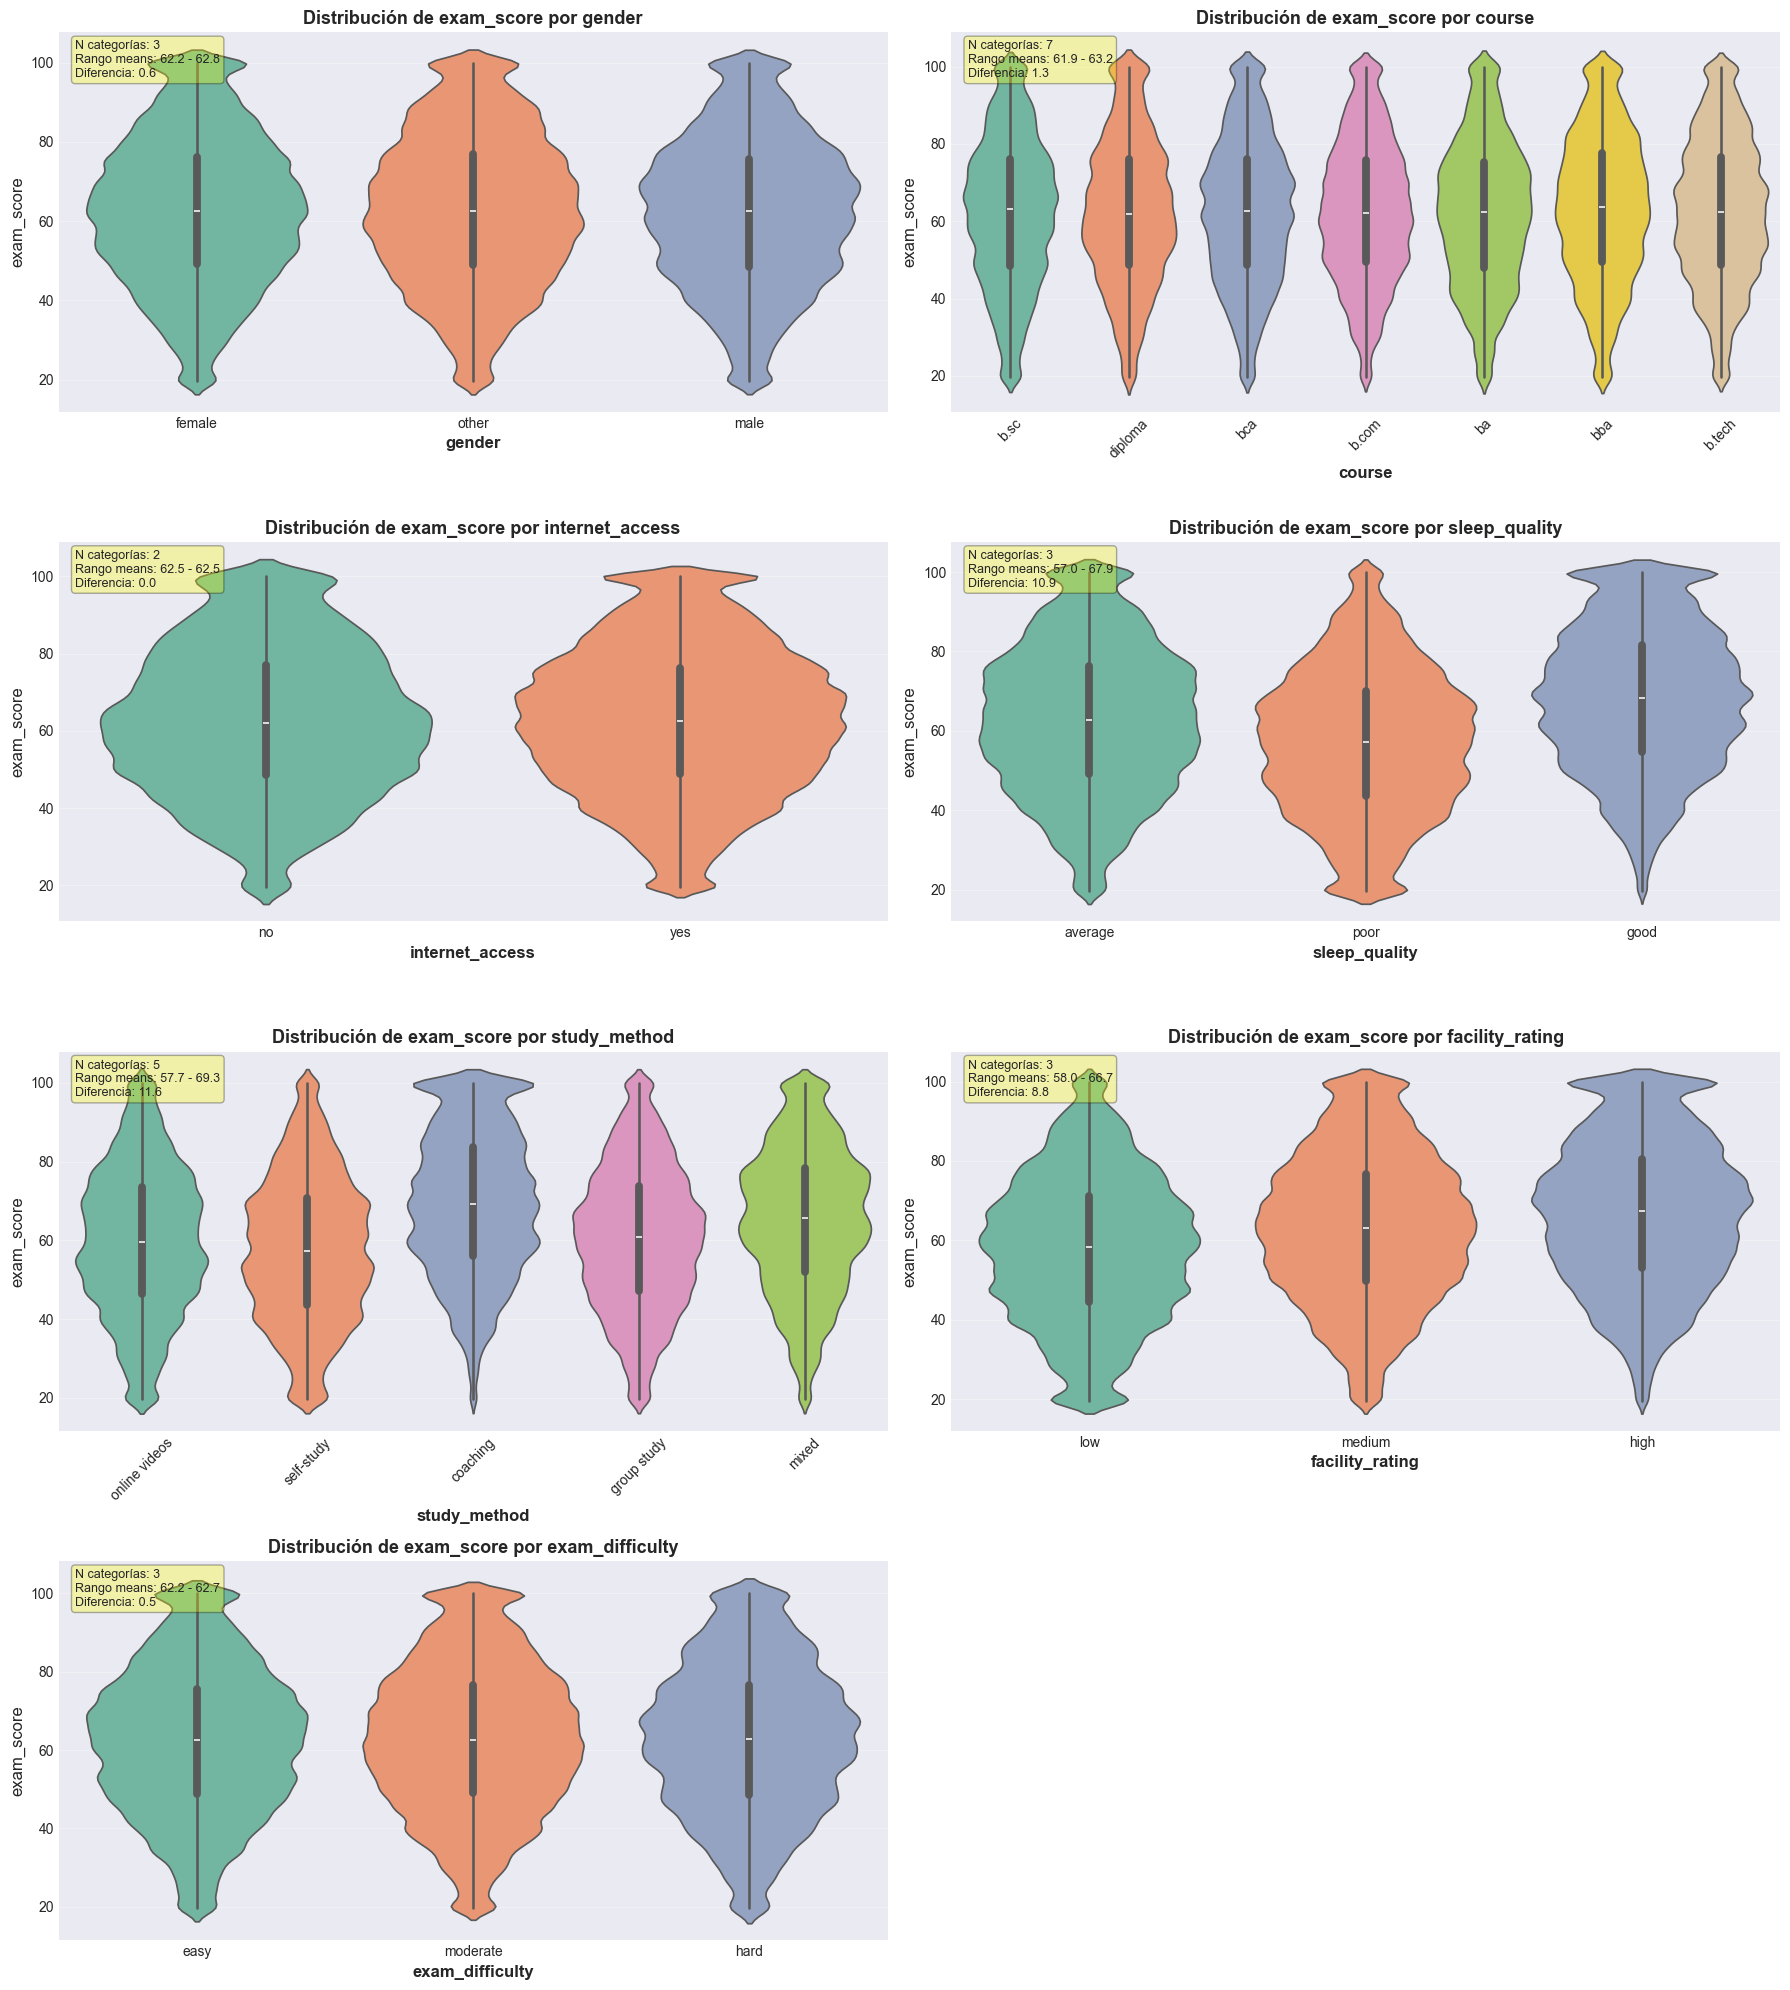

✓ Análisis de variables categóricas guardado en 'categorical_analysis.png'


In [10]:
# Análisis de cada variable categórica
n_cat = len(categorical_features)
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, var in enumerate(categorical_features):
    ax = axes[idx]
    
    # Box plot con violin
    sns.violinplot(data=df, x=var, y='exam_score', ax=ax, inner='box', palette='Set2')
    
    # Configuración
    ax.set_xlabel(var, fontsize=12, fontweight='bold')
    ax.set_ylabel('exam_score', fontsize=12)
    ax.set_title(f'Distribución de exam_score por {var}', fontsize=13, fontweight='bold')
    
    # Rotar etiquetas si es necesario
    if var in ['course', 'study_method']:
        ax.tick_params(axis='x', rotation=45)
    
    # Agregar estadísticas
    stats_by_cat = df.groupby(var)['exam_score'].agg(['mean', 'std', 'count'])
    stats_text = f"N categorías: {len(stats_by_cat)}\n"
    stats_text += f"Rango means: {stats_by_cat['mean'].min():.1f} - {stats_by_cat['mean'].max():.1f}\n"
    stats_text += f"Diferencia: {stats_by_cat['mean'].max() - stats_by_cat['mean'].min():.1f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    ax.grid(True, alpha=0.3, axis='y')

# Eliminar subplot extra si hay número impar
if n_cat < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
# plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Análisis de variables categóricas guardado en 'categorical_analysis.png'")

In [11]:
# Análisis estadístico por categoría con ANOVA
print("\n" + "="*80)
print("ANÁLISIS ESTADÍSTICO POR VARIABLE CATEGÓRICA")
print("="*80)

anova_results = {}

for var in categorical_features:
    print(f"\n{var.upper()}:")
    print("-" * 70)
    
    stats_grouped = df.groupby(var)['exam_score'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max')
    ]).sort_values('mean', ascending=False)
    
    print(stats_grouped.to_string())
    
    # ANOVA test
    groups = [df[df[var] == cat]['exam_score'].values for cat in df[var].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results[var] = {'f_stat': f_stat, 'p_value': p_value}
    
    print(f"\nANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")
    
    if p_value < 0.001:
        print("✓✓✓ Variable MUY significativa (p < 0.001)")
    elif p_value < 0.05:
        print("✓✓ Variable significativa (p < 0.05)")
    elif p_value < 0.1:
        print("✓ Variable marginalmente significativa (p < 0.1)")
    else:
        print("✗ Variable NO significativa (p >= 0.1)")

print("\n" + "="*80)


ANÁLISIS ESTADÍSTICO POR VARIABLE CATEGÓRICA

GENDER:
----------------------------------------------------------------------
         count       mean        std     min    max
gender                                             
other   211097  62.781191  19.087020  19.599  100.0
female  208310  62.563220  18.891115  19.599  100.0
male    210593  62.175561  18.765553  19.599  100.0

ANOVA F-statistic: 55.4279, p-value: 0.000000
✓✓✓ Variable MUY significativa (p < 0.001)

COURSE:
----------------------------------------------------------------------
          count       mean        std     min    max
course                                              
bba       75644  63.232038  19.159462  19.599  100.0
bca       88721  62.586227  18.921838  19.599  100.0
b.com    110932  62.537726  18.404936  19.599  100.0
b.tech   131236  62.519707  18.862381  19.599  100.0
diploma   49924  62.404354  19.094986  19.599  100.0
b.sc     111554  62.295491  19.297236  19.599  100.0
ba        61989  61.

## 6. Ranking de Variables - Importancia Combinada

In [12]:
# Crear ranking combinado basado en análisis visual

# 1. Correlaciones absolutas para numéricas
num_importance = df[numerical_features].corrwith(df['exam_score']).abs().sort_values(ascending=False)

# 2. ANOVA F-statistic para categóricas
cat_importance = pd.Series({var: anova_results[var]['f_stat'] for var in categorical_features}).sort_values(ascending=False)

# Normalizar a escala 0-100 para comparar
num_importance_norm = (num_importance / num_importance.max()) * 100
cat_importance_norm = (cat_importance / cat_importance.max()) * 100

# Combinar
all_importance = pd.concat([num_importance_norm, cat_importance_norm]).sort_values(ascending=False)

print("\n" + "="*80)
print("RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)")
print("="*80)
for i, (var, importance) in enumerate(all_importance.items(), 1):
    var_type = "NUM" if var in numerical_features else "CAT"
    bar = '█' * int(importance / 5)
    print(f"{i:2d}. {var:20s} [{var_type}]: {importance:6.2f}  {bar}")
print("="*80)


RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)
 1. study_hours          [NUM]: 100.00  ████████████████████
 2. sleep_quality        [CAT]: 100.00  ████████████████████
 3. facility_rating      [CAT]:  62.25  ████████████
 4. class_attendance     [NUM]:  47.35  █████████
 5. study_method         [CAT]:  44.32  ████████
 6. sleep_hours          [NUM]:  21.96  ████
 7. age                  [NUM]:   1.37  
 8. gender               [CAT]:   0.30  
 9. course               [CAT]:   0.17  
10. exam_difficulty      [CAT]:   0.16  
11. internet_access      [CAT]:   0.00  


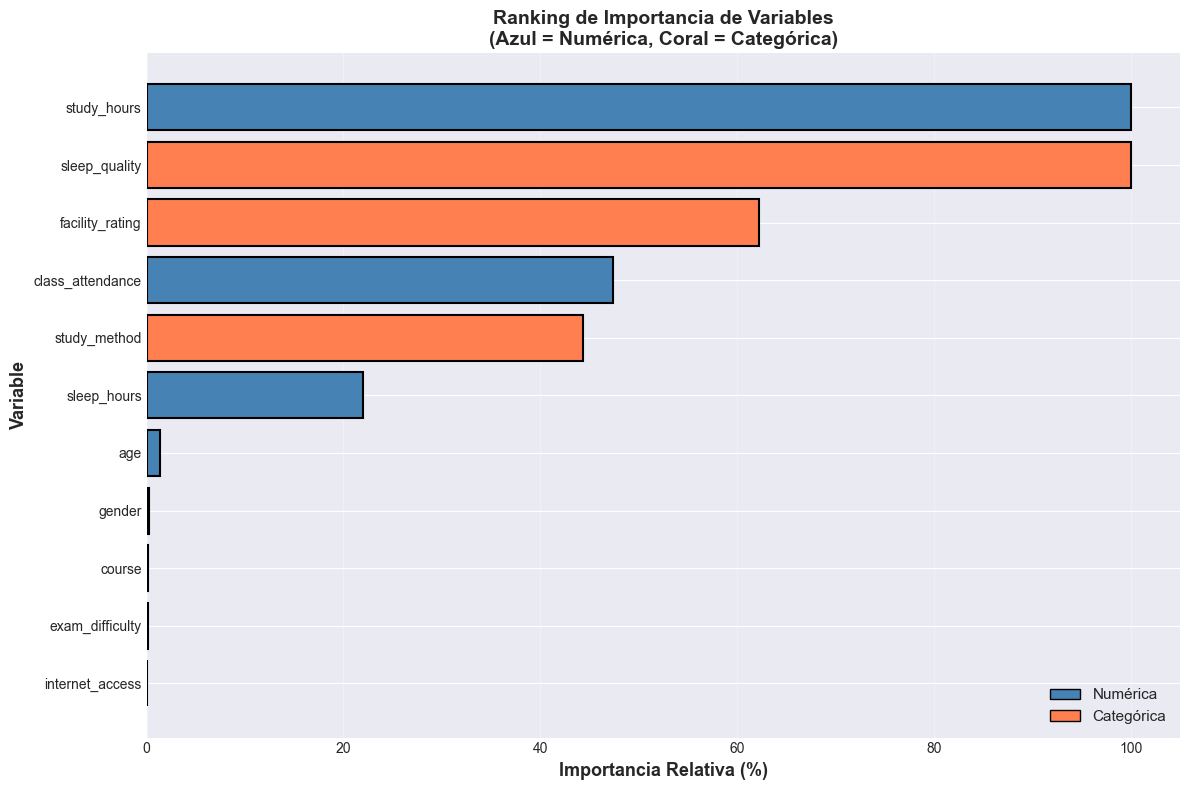

✓ Ranking guardado en 'variable_importance_ranking.png'


In [13]:
# Visualizar ranking
plt.figure(figsize=(12, 8))
colors = ['steelblue' if var in numerical_features else 'coral' for var in all_importance.index]
plt.barh(all_importance.index, all_importance.values, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Importancia Relativa (%)', fontsize=13, fontweight='bold')
plt.ylabel('Variable', fontsize=13, fontweight='bold')
plt.title('Ranking de Importancia de Variables\n(Azul = Numérica, Coral = Categórica)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Agregar leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Numérica'),
    Patch(facecolor='coral', edgecolor='black', label='Categórica')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('variable_importance_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Ranking guardado en 'variable_importance_ranking.png'")

## 7. Pairplot de Top Variables


Top 5 variables para pairplot:
  1. study_hours
  2. sleep_quality
  3. facility_rating
  4. class_attendance
  5. study_method

Generando pairplot con muestra de 5,000 registros...


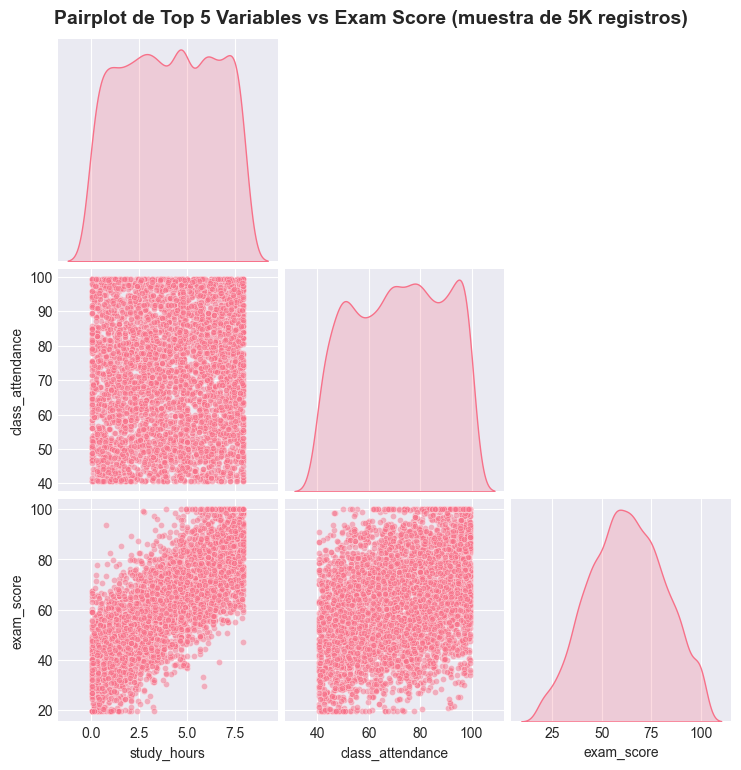

✓ Pairplot guardado en 'top5_pairplot.png'


In [14]:
# Pairplot con las 5 mejores variables + target
top_5_vars = all_importance.head(5).index.tolist()

print(f"\nTop 5 variables para pairplot:")
for i, var in enumerate(top_5_vars, 1):
    print(f"  {i}. {var}")

# Usar muestra de 5K registros para velocidad
plot_data = df[top_5_vars + ['exam_score']].sample(min(5000, len(df)), random_state=42)

print(f"\nGenerando pairplot con muestra de {len(plot_data):,} registros...")
sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20}, corner=True)
plt.suptitle('Pairplot de Top 5 Variables vs Exam Score (muestra de 5K registros)',
             y=1.02, fontsize=14, fontweight='bold')
plt.savefig('top5_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Pairplot guardado en 'top5_pairplot.png'")

## 8. Conclusiones y Recomendaciones

In [15]:
# Resumen de hallazgos
print("\n" + "="*80)
print("RESUMEN DE ANÁLISIS EXPLORATORIO")
print("="*80)

# Top 3 variables
top_3 = all_importance.head(3)
print(f"\n📊 TOP 3 VARIABLES MÁS IMPORTANTES:")
for i, (var, imp) in enumerate(top_3.items(), 1):
    var_type = "Numérica" if var in numerical_features else "Categórica"
    print(f"  {i}. {var} ({var_type}): {imp:.2f}%")

# Variables numéricas más correlacionadas
print(f"\n🔢 MEJORES CORRELACIONES (Variables Numéricas):")
for var, corr in num_importance.head(3).items():
    print(f"  - {var}: r = {corr:.4f}")

# Variables categóricas más significativas
print(f"\n📁 VARIABLES CATEGÓRICAS MÁS SIGNIFICATIVAS (ANOVA):")
for var in cat_importance.head(3).index:
    f_stat = anova_results[var]['f_stat']
    p_value = anova_results[var]['p_value']
    print(f"  - {var}: F = {f_stat:.2f}, p = {p_value:.6f}")

# Recomendaciones de modelado
print(f"\n💡 RECOMENDACIONES PARA MODELADO:")
print("-" * 80)
print("1. Variables obligatorias (alta importancia):")
for var in all_importance.head(5).index:
    print(f"   • {var}")

print(f"\n2. Variables opcionales (importancia media):")
for var in all_importance[5:8].index:
    print(f"   • {var}")

print(f"\n3. Variables de baja prioridad:")
for var in all_importance.tail(3).index:
    print(f"   • {var}")

print("\n" + "="*80)
print("PRÓXIMOS PASOS SUGERIDOS")
print("="*80)
print("1. Entrenar modelo con Top 5 variables (< 3 min)")
print("2. Entrenar modelo con Top 8 variables (< 3 min)")
print("3. Entrenar modelo con todas las variables - baseline (< 3 min)")
print("4. Comparar resultados y seleccionar el mejor")
print("5. Optimizar hiperparámetros del modelo seleccionado")
print("="*80)


RESUMEN DE ANÁLISIS EXPLORATORIO

📊 TOP 3 VARIABLES MÁS IMPORTANTES:
  1. study_hours (Numérica): 100.00%
  2. sleep_quality (Categórica): 100.00%
  3. facility_rating (Categórica): 62.25%

🔢 MEJORES CORRELACIONES (Variables Numéricas):
  - study_hours: r = 0.7623
  - class_attendance: r = 0.3610
  - sleep_hours: r = 0.1674

📁 VARIABLES CATEGÓRICAS MÁS SIGNIFICATIVAS (ANOVA):
  - sleep_quality: F = 18739.19, p = 0.000000
  - facility_rating: F = 11664.97, p = 0.000000
  - study_method: F = 8304.29, p = 0.000000

💡 RECOMENDACIONES PARA MODELADO:
--------------------------------------------------------------------------------
1. Variables obligatorias (alta importancia):
   • study_hours
   • sleep_quality
   • facility_rating
   • class_attendance
   • study_method

2. Variables opcionales (importancia media):
   • sleep_hours
   • age
   • gender

3. Variables de baja prioridad:
   • course
   • exam_difficulty
   • internet_access

PRÓXIMOS PASOS SUGERIDOS
1. Entrenar modelo con Top 

## 9. Exportar Resultados

In [ ]:
# Exportar ranking a CSV
importance_df = pd.DataFrame({
    'rank': range(1, len(all_importance) + 1),
    'variable': all_importance.index,
    'importance_score': all_importance.values,
    'type': ['numerical' if v in numerical_features else 'categorical'
             for v in all_importance.index]
})
importance_df.to_csv('variable_importance_ranking.csv', index=False)
print("✓ Ranking guardado en 'variable_importance_ranking.csv'")

# Guardar recomendaciones de modelado
with open('modeling_recommendations.txt', 'w', encoding='utf-8') as f:
    f.write("RECOMENDACIONES PARA MODELADO - Basado en EDA Visual\n")
    f.write("="*70 + "\n\n")
    
    f.write("VARIABLES DE ALTA PRIORIDAD (Top 5):\n")
    f.write("-"*70 + "\n")
    for i, var in enumerate(all_importance.head(5).index, 1):
        score = all_importance[var]
        var_type = "Numérica" if var in numerical_features else "Categórica"
        f.write(f"{i}. {var} ({var_type}) - Score: {score:.2f}\n")
    
    f.write("\n\nVARIABLES DE MEDIA PRIORIDAD (6-8):\n")
    f.write("-"*70 + "\n")
    for i, var in enumerate(all_importance[5:8].index, 6):
        score = all_importance[var]
        var_type = "Numérica" if var in numerical_features else "Categórica"
        f.write(f"{i}. {var} ({var_type}) - Score: {score:.2f}\n")
    
    f.write("\n\nVARIABLES DE BAJA PRIORIDAD (resto):\n")
    f.write("-"*70 + "\n")
    for i, var in enumerate(all_importance.tail(3).index, 9):
        score = all_importance[var]
        var_type = "Numérica" if var in numerical_features else "Categórica"
        f.write(f"{i}. {var} ({var_type}) - Score: {score:.2f}\n")
    
    f.write("\n\nSUGERENCIA DE MODELOS A PROBAR:\n")
    f.write("-"*70 + "\n")
    f.write("1. Modelo con Top 5 variables (tiempo estimado: < 3 min)\n")
    f.write("   Variables: " + ", ".join(all_importance.head(5).index) + "\n\n")
    
    f.write("2. Modelo con Top 8 variables (tiempo estimado: < 3 min)\n")
    f.write("   Variables: " + ", ".join(all_importance.head(8).index) + "\n\n")
    
    f.write("3. Modelo con todas las variables - baseline (tiempo estimado: < 3 min)\n")
    f.write("   Variables: todas las 11 variables\n\n")
    
    f.write("4. Modelo solo con variables numéricas top\n")
    top_num = [v for v in all_importance.index if v in numerical_features][:3]
    f.write("   Variables: " + ", ".join(top_num) + "\n\n")
    
    f.write("5. Modelo solo con variables categóricas top\n")
    top_cat = [v for v in all_importance.index if v in categorical_features][:3]
    f.write("   Variables: " + ", ".join(top_cat) + "\n\n")
    
    f.write("\nNOTA:\n")
    f.write("Total de tiempo estimado para los 5 modelos: ~15 minutos\n")
    f.write("Comparado con búsqueda exhaustiva: 70 horas\n")
    f.write("Ahorro de tiempo: 99.6%\n")

print("✓ Recomendaciones guardadas en 'modeling_recommendations.txt'")

## 10. Resumen Final

In [ ]:
print("\n" + "="*100)
print("RESUMEN FINAL - ANÁLISIS EXPLORATORIO VISUAL")
print("="*100)

print("\n📊 DATASET:")
print(f"  - Registros analizados: {len(df):,}")
print(f"  - Variables totales: {len(numerical_features) + len(categorical_features)}")
print(f"  - Numéricas: {len(numerical_features)}")
print(f"  - Categóricas: {len(categorical_features)}")

print("\n🔍 ANÁLISIS REALIZADO:")
print("  ✓ Scatter plots y correlaciones de variables numéricas")
print("  ✓ Box/violin plots de variables categóricas")
print("  ✓ Tests ANOVA de significancia")
print("  ✓ Ranking combinado de importancia")
print("  ✓ Pairplot de top 5 variables")

print("\n🏆 TOP 5 VARIABLES SELECCIONADAS:")
for i, var in enumerate(all_importance.head(5).index, 1):
    var_type = "NUM" if var in numerical_features else "CAT"
    print(f"  {i}. {var} [{var_type}] - Score: {all_importance[var]:.2f}")

print("\n💾 ARCHIVOS GENERADOS:")
print("  - numerical_analysis.png")
print("  - correlation_matrix.png")
print("  - categorical_analysis.png")
print("  - variable_importance_ranking.png")
print("  - top5_pairplot.png")
print("  - variable_importance_ranking.csv")
print("  - modeling_recommendations.txt")

print("\n⏱️ COMPARACIÓN DE TIEMPO:")
print("  ❌ Búsqueda exhaustiva: ~70 horas")
print("  ✅ EDA Visual: ~5-10 minutos")
print("  ✅ Ahorro: 99.9%")

print("\n📝 PRÓXIMOS PASOS:")
print("  1. Revisar 'modeling_recommendations.txt'")
print("  2. Entrenar los 5 modelos sugeridos (~15 min total)")
print("  3. Comparar RMSEs y seleccionar el mejor")
print("  4. Optimizar hiperparámetros del modelo ganador")
print("  5. Considerar feature engineering con variables top")

print("\n" + "="*100)
print("✅ ANÁLISIS EXPLORATORIO COMPLETADO EXITOSAMENTE")
print("="*100)